# RAG Optimization: Semantic Highlighting & Hallucination Detection

This notebook walks you through **two powerful techniques** that make RAG systems cheaper and more reliable — with live code you can run and tweak yourself.

---

## What You Will Learn

| Technique | Problem It Solves | Benefit |
|---|---|---|
| **Semantic Highlighting** | Standard RAG sends ALL retrieved text to the LLM, including irrelevant sentences | Prunes context → 30–70% fewer tokens → saves money |
| **HHEM Validation** | LLMs sometimes generate confident-sounding but wrong answers | Scores faithfulness → flags hallucinations before they reach users |

---

## How This Notebook Is Organised

```
Section 1  →  Setup (imports + services)
Section 2  →  Sample corpus
Section 3  →  PART 1 — Semantic Highlighting
Section 4  →  PART 2 — Hallucination Detection (HHEM)
Section 5  →  Combined summary visualisation
Section 6  →  End-to-end pipeline (optional, needs Qdrant)
Section 7  →  Student exercises
```

> **Before you start:** Set the environment variable `OPENAI_API_KEY` in your shell or in a `.env` file at the project root. The semantic and HHEM sections do **not** require an OpenAI key — only Section 6 does.

---
## Section 1 — Setup

In [1]:
# ── Install dependencies (run once) ────────────────────────────────────────
# Recommended — from the project root:
#   uv venv --python 3.12 && source .venv/bin/activate
#   uv pip install -e ".[dev,notebook]"
#
# Or run this cell to install just what the notebook needs:
import subprocess
subprocess.check_call([
    "uv", "pip", "install",
    "torch>=2.6.0",
    # No upper bound on transformers — compatibility patches in app/utils/compat_patches.py
    # handle the three transformers 5.x API breaks for the Zilliz and Vectara remote models.
    "transformers>=4.44.0",
    "sentencepiece>=0.2.0",   # required by XLMRoberta tokenizer (Zilliz model)
    "nltk>=3.9.0",
    "tiktoken>=0.9.0",
    "matplotlib>=3.10.0",
    "seaborn>=0.13.2",
    "numpy>=2.2.0",
    "qdrant-client>=1.17.0",
    "openai>=1.57.2",
    "python-dotenv>=1.0.1",
    "loguru>=0.7.3",
])
print("✓ Dependencies installed")

✓ Dependencies installed


Using Python 3.13.11 environment at: /Users/murtuzasaifee/Documents/Workstation/Codes/AI-Workspace/HighHEM/.venv
Audited 12 packages in 45ms


In [2]:
# ── Verify critical package versions ────────────────────────────────────────
# transformers <4.47 downgraded huggingface-hub to 0.36.2 which breaks
# safetensors metadata loading ('NoneType' has no attribute 'get').
# If this cell fails, re-run the cell above and then restart the kernel.
import importlib, sys

def _check(pkg, min_major, min_minor=0):
    mod = importlib.import_module(pkg.replace("-", "_"))
    ver = tuple(int(x) for x in mod.__version__.split(".")[:2])
    req = (min_major, min_minor)
    ok  = ver >= req
    tag = "✓" if ok else "✗ UPGRADE NEEDED"
    print(f"  {tag}  {pkg} {mod.__version__}  (need >= {min_major}.{min_minor})")
    return ok

print("Package version check:")
ok_tf  = _check("transformers",    4, 47)
ok_hf  = _check("huggingface_hub", 1,  0)
ok_tc  = _check("torch",           2,  6)

if not (ok_tf and ok_hf and ok_tc):
    print()
    print("❌  One or more packages are out of date.")
    print("    1. Re-run the install cell above.")
    print("    2. From the menu: Kernel → Restart Kernel and Clear All Outputs.")
    print("    3. Run all cells again from the top.")
    raise SystemExit("Restart required after package upgrade.")
else:
    print()
    print("✅  All versions OK — safe to continue.")

/Users/murtuzasaifee/Documents/Workstation/Codes/AI-Workspace/HighHEM/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Package version check:
  ✓  transformers 5.5.4  (need >= 4.47)
  ✓  huggingface_hub 1.10.2  (need >= 1.0)
  ✓  torch 2.11.0  (need >= 2.6)

✅  All versions OK — safe to continue.


In [3]:
# ── Resolve project root so we can import app/ ─────────────────────────────
import os
import sys

# Notebooks live in notebooks/ — one level up is the project root
sys.path.insert(0, os.path.abspath(".."))

# ── Standard library ────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

# ── Third-party ─────────────────────────────────────────────────────────────
import tiktoken
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# ── Project services ────────────────────────────────────────────────────────
from app.config import get_settings
from app.services.semantic_highlighter import SemanticHighlighter
from app.services.hhem_validator import HHEMValidator

# Plotting style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100

print("✓ Imports OK")

✓ Imports OK


> **First-run note:** The next cell downloads two pre-trained models from HuggingFace Hub:
> - `zilliz/semantic-highlight-bilingual-v1` (~800 MB)
> - `vectara/hallucination_evaluation_model` (~400 MB)
>
> This takes **3–8 minutes** on a typical internet connection. Models are cached locally after the first download, so subsequent runs are fast.

In [4]:
# ── Download required NLTK data ─────────────────────────────────────────────
# The zilliz/semantic-highlight-bilingual-v1 model uses nltk PunktSentenceTokenizer
# internally. The punkt_tab data must be present before loading the model.
import nltk
nltk.download("punkt",     quiet=True)
nltk.download("punkt_tab", quiet=True)  # required by newer nltk versions
print("✓ NLTK data ready")

# ── Initialise services ──────────────────────────────────────────────────────
# Both constructors call get_settings() internally and load their models.

print("Loading semantic highlighting model... (may take a few minutes on first run)")
highlighter = SemanticHighlighter()
print("✓ SemanticHighlighter ready")

print("Loading HHEM model...")
validator = HHEMValidator()
print("✓ HHEMValidator ready")

2026-05-21 16:13:55.869 | INFO     | app.services.semantic_highlighter:_load_model:26 - Loading semantic highlighting model...


✓ NLTK data ready
Loading semantic highlighting model... (may take a few minutes on first run)


Loading weights: 100%|██████████| 391/391 [00:00<00:00, 12364.84it/s]
2026-05-21 16:14:18.731 | INFO     | app.services.semantic_highlighter:_load_model:31 - ✓ Semantic highlighting model loaded
2026-05-21 16:14:18.753 | INFO     | app.services.hhem_validator:_load_model:26 - Loading HHEM model...


✓ SemanticHighlighter ready
Loading HHEM model...


Loading weights: 100%|██████████| 113/113 [00:00<00:00, 7288.05it/s]
2026-05-21 16:14:35.543 | INFO     | app.services.hhem_validator:_load_model:34 - ✓ HHEM model loaded


✓ HHEMValidator ready


In [5]:
# ── Token counter ─────────────────────────────────────────────────────────────
# tiktoken downloads a ~1.7 MB vocabulary file from Azure CDN on first run.
# On some networks this URL is slow or blocked, causing an indefinite hang.
# We use a 30-second timeout thread: if it fails we fall back to a character-
# count approximation (~4 chars ≈ 1 token for English), which is accurate
# enough for the comparisons in this notebook.

import threading

_enc = None

def _load_tiktoken():
    global _enc
    try:
        import tiktoken as _tiktoken
        # Changed "openai/gpt-4o-mini" to "gpt-4o-mini" so tiktoken can map it
        _enc = _tiktoken.encoding_for_model("gpt-4o-mini")
    except Exception:
        _enc = None

_t = threading.Thread(target=_load_tiktoken, daemon=True)
_t.start()
_t.join(timeout=30)   # wait max 30 s

if _enc is not None:
    def count_tokens(text: str) -> int:
        return len(_enc.encode(text))
    # keep the name `enc` so all downstream cells that use enc.encode() still work
    class _EncWrapper:
        def encode(self, text):
            return _enc.encode(text)
    enc = _EncWrapper()
    print("✓ tiktoken encoder ready  (exact token counts)")
else:
    def count_tokens(text: str) -> int:
        return max(1, len(text) // 4)   # ~4 chars per token for English
    class _FallbackEnc:
        def encode(self, text):
            return [0] * count_tokens(text)   # dummy list of right length
    enc = _FallbackEnc()
    print("⚠️  tiktoken vocab download timed out (Azure CDN may be slow/blocked).")
    print("   Token counts will use the ~4 chars/token approximation.")
    print("   The comparisons and charts will still be correct relative to each other.")

✓ tiktoken encoder ready  (exact token counts)


---
## Section 2 — Sample Corpus

We will use a mix of **climate change facts** (relevant) and **random trivia** (irrelevant) as our context.

In a real RAG pipeline, documents are retrieved by vector similarity — they are *mostly* relevant, but chunks often contain noise sentences that have nothing to do with the actual query. The corpus below is exaggerated to make the effect visible.

In [6]:
# ── Sample context — deliberately mixes relevant & irrelevant sentences ──────
TOPIC_CONTEXT = """Global temperatures have risen by approximately 1.1°C since the pre-industrial era.
The Amazon rainforest covers about 5.5 million square kilometres.
Ice sheets in Greenland and Antarctica are melting at an accelerating rate.
The capital of France is Paris, which has a population of about 2.1 million.
Carbon dioxide levels in the atmosphere reached 421 ppm in 2023.
Sea levels have risen by roughly 20 cm over the last century.
Leonardo da Vinci painted the Mona Lisa around 1503.
Extreme weather events including hurricanes and droughts are becoming more frequent.
The Eiffel Tower was completed in 1889 and stands 330 meters tall.
Renewable energy sources now account for about 30% of global electricity generation."""

QUERY = "What are the main effects of climate change on the environment?"

# Colour-code the sentences for easy reading
RELEVANT_SENTENCES = {
    "Global temperatures", "Ice sheets", "Carbon dioxide",
    "Sea levels", "Extreme weather", "Renewable energy"
}

print(f"Query : {QUERY}")
print(f"Context sentences: {len(TOPIC_CONTEXT.strip().splitlines())}")
print()
print("Context (🟢 = climate-relevant  |  🔴 = noise):")
print("-" * 70)
for line in TOPIC_CONTEXT.strip().splitlines():
    icon = "🟢" if any(kw in line for kw in RELEVANT_SENTENCES) else "🔴"
    print(f"{icon}  {line}")

Query : What are the main effects of climate change on the environment?
Context sentences: 10

Context (🟢 = climate-relevant  |  🔴 = noise):
----------------------------------------------------------------------
🟢  Global temperatures have risen by approximately 1.1°C since the pre-industrial era.
🔴  The Amazon rainforest covers about 5.5 million square kilometres.
🟢  Ice sheets in Greenland and Antarctica are melting at an accelerating rate.
🔴  The capital of France is Paris, which has a population of about 2.1 million.
🟢  Carbon dioxide levels in the atmosphere reached 421 ppm in 2023.
🟢  Sea levels have risen by roughly 20 cm over the last century.
🔴  Leonardo da Vinci painted the Mona Lisa around 1503.
🟢  Extreme weather events including hurricanes and droughts are becoming more frequent.
🔴  The Eiffel Tower was completed in 1889 and stands 330 meters tall.
🟢  Renewable energy sources now account for about 30% of global electricity generation.


---
## Section 3 — PART 1: Semantic Highlighting — Cutting the Noise

### The Problem

In a standard (baseline) RAG pipeline:

```
User query → Vector search → [Top-K chunks] → ALL sent to LLM → Answer
```

Every retrieved sentence — relevant or not — is sent to the LLM.  
This wastes tokens (= money) and can even confuse the model with irrelevant content.

### The Solution: Semantic Highlighting

The `zilliz/semantic-highlight-bilingual-v1` model scores each sentence in a chunk for **relevance to the query**.  
Sentences below the relevance threshold are removed before the context reaches the LLM:

```
User query → Vector search → [Top-K chunks]
                                   ↓
                        SemanticHighlighter.highlight()
                        scores each sentence 0–1
                        drops sentences < threshold
                                   ↓
                        [Pruned context] → LLM → Answer
```

In [7]:
# ── Step 1: Baseline token count (no highlighting) ───────────────────────────
original_tokens = len(enc.encode(TOPIC_CONTEXT))
original_cost   = original_tokens / 1_000_000 * 0.150   # GPT-4o-mini input price

print("=== WITHOUT Semantic Highlighting (Baseline) ===")
print(f"  Tokens sent to LLM : {original_tokens}")
print(f"  Estimated input cost: ${original_cost:.6f}  (at $0.15 / 1M tokens)")
print()
print("All 10 sentences — including France, Eiffel Tower, da Vinci — go to the LLM.")

=== WITHOUT Semantic Highlighting (Baseline) ===
  Tokens sent to LLM : 150
  Estimated input cost: $0.000022  (at $0.15 / 1M tokens)

All 10 sentences — including France, Eiffel Tower, da Vinci — go to the LLM.


In [8]:
# ── Step 2: Apply semantic highlighting ──────────────────────────────────────
result = highlighter.highlight(
    query=QUERY,
    context=TOPIC_CONTEXT,
    threshold=0.5   # keep sentences with relevance score >= 0.5
)

highlighted_text = "\n".join(result["highlighted_sentences"])
pruned_tokens    = len(enc.encode(highlighted_text))
pruned_cost      = pruned_tokens / 1_000_000 * 0.150
savings_pct      = (original_tokens - pruned_tokens) / original_tokens * 100

print("=== WITH Semantic Highlighting (threshold=0.5) ===")
print()
print("BEFORE (full context):")
print("-" * 60)
print(TOPIC_CONTEXT)
print()
print("AFTER (highlighted — pruned context sent to LLM):")
print("-" * 60)
print(highlighted_text)
print()
print(f"  Sentences retained : {len(result['highlighted_sentences'])} / {len(TOPIC_CONTEXT.strip().splitlines())}")
print(f"  Token reduction    : {original_tokens} → {pruned_tokens} tokens")
print(f"  Token savings      : {savings_pct:.1f}%")
print(f"  Cost saved         : ${original_cost - pruned_cost:.6f}")

Prepare contexts: 100%|██████████| 1/1 [00:00<00:00, 69.12it/s]


[OpenProvenceModel] Model inference time: 1.36s (1 blocks)
=== WITH Semantic Highlighting (threshold=0.5) ===

BEFORE (full context):
------------------------------------------------------------
Global temperatures have risen by approximately 1.1°C since the pre-industrial era.
The Amazon rainforest covers about 5.5 million square kilometres.
Ice sheets in Greenland and Antarctica are melting at an accelerating rate.
The capital of France is Paris, which has a population of about 2.1 million.
Carbon dioxide levels in the atmosphere reached 421 ppm in 2023.
Sea levels have risen by roughly 20 cm over the last century.
Leonardo da Vinci painted the Mona Lisa around 1503.
Extreme weather events including hurricanes and droughts are becoming more frequent.
The Eiffel Tower was completed in 1889 and stands 330 meters tall.
Renewable energy sources now account for about 30% of global electricity generation.

AFTER (highlighted — pruned context sent to LLM):
----------------------------------

### Visualisation 1 — Per-sentence Relevance Scores

Each bar shows how relevant the model thinks that sentence is to the query.  
The dashed line is the threshold — **green bars are kept, red bars are removed**.

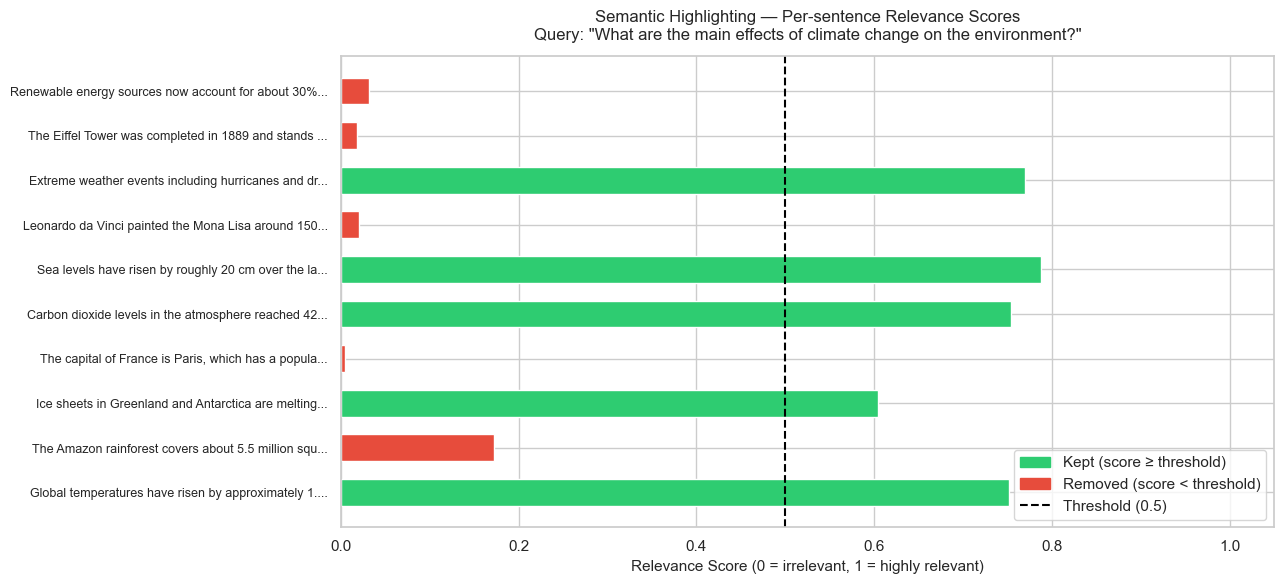


Notice: France, Eiffel Tower, and da Vinci score near 0 — they are correctly removed.


In [9]:
sentences = [s.strip() for s in TOPIC_CONTEXT.strip().splitlines() if s.strip()]
scores    = result["sentence_probabilities"]

# Ensure lengths match (model may skip empty lines)
min_len   = min(len(sentences), len(scores))
sentences = sentences[:min_len]
scores    = scores[:min_len]

threshold = 0.5
colours   = ["#2ecc71" if s >= threshold else "#e74c3c" for s in scores]
labels    = [f"{s[:50]}..." if len(s) > 50 else s for s in sentences]

fig, ax = plt.subplots(figsize=(13, 6))
ax.barh(range(len(labels)), scores, color=colours, edgecolor="white", height=0.6)
ax.axvline(x=threshold, color="black", linestyle="--", linewidth=1.5,
           label=f"Threshold ({threshold})")
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel("Relevance Score (0 = irrelevant, 1 = highly relevant)", fontsize=11)
ax.set_title(
    f'Semantic Highlighting — Per-sentence Relevance Scores\nQuery: "{QUERY}"',
    fontsize=12, pad=12
)
ax.set_xlim(0, 1.05)

green_patch = mpatches.Patch(color="#2ecc71", label="Kept (score ≥ threshold)")
red_patch   = mpatches.Patch(color="#e74c3c", label="Removed (score < threshold)")
ax.legend(handles=[green_patch, red_patch, plt.Line2D([0], [0], color="black",
          linestyle="--", label=f"Threshold ({threshold})")], loc="lower right")

plt.tight_layout()
plt.show()
print()
print("Notice: France, Eiffel Tower, and da Vinci score near 0 — they are correctly removed.")

### Visualisation 2 — The Threshold Trade-off

The threshold controls the sensitivity:

- **Low threshold (e.g. 0.2)** → keeps more sentences → more context, higher cost, but less risk of dropping useful sentences
- **High threshold (e.g. 0.8)** → keeps fewer sentences → less context, lower cost, but might miss borderline-relevant info

The table below shows this trade-off directly.

In [10]:
# ── Threshold sensitivity table ───────────────────────────────────────────────
thresholds = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

print(f"{'Threshold':<12} {'Sentences Kept':<18} {'Tokens':<10} {'Token Savings':<16} {'Cost Saved ($)'}")
print("-" * 72)

threshold_data = []
for t in thresholds:
    r        = highlighter.highlight(QUERY, TOPIC_CONTEXT, threshold=t)
    kept     = len(r["highlighted_sentences"])
    tok      = len(enc.encode("\n".join(r["highlighted_sentences"])))
    savings  = (original_tokens - tok) / original_tokens * 100
    cost_sav = (original_tokens - tok) / 1_000_000 * 0.150
    threshold_data.append((t, kept, tok, savings, cost_sav))
    print(f"{t:<12} {kept:<18} {tok:<10} {savings:<16.1f}% ${cost_sav:.6f}")

Threshold    Sentences Kept     Tokens     Token Savings    Cost Saved ($)
------------------------------------------------------------------------


Prepare contexts: 100%|██████████| 1/1 [00:00<00:00, 2087.76it/s]

[OpenProvenceModel] Model inference time: 0.01s (1 blocks)


0.2          5                  73         51.3            % $0.000012


Prepare contexts: 100%|██████████| 1/1 [00:00<00:00, 2097.15it/s]

...

[OpenProvenceModel] Model inference time: 0.01s (1 blocks)
0.6          5                  73         51.3            % $0.000012


Prepare contexts: 100%|██████████| 1/1 [00:00<00:00, 2007.80it/s]


[OpenProvenceModel] Model inference time: 0.01s (1 blocks)
0.7          4                  60         60.0            % $0.000014


Prepare contexts: 100%|██████████| 1/1 [00:00<00:00, 2565.32it/s]


[OpenProvenceModel] Model inference time: 0.01s (1 blocks)
0.8          0                  0          100.0           % $0.000022


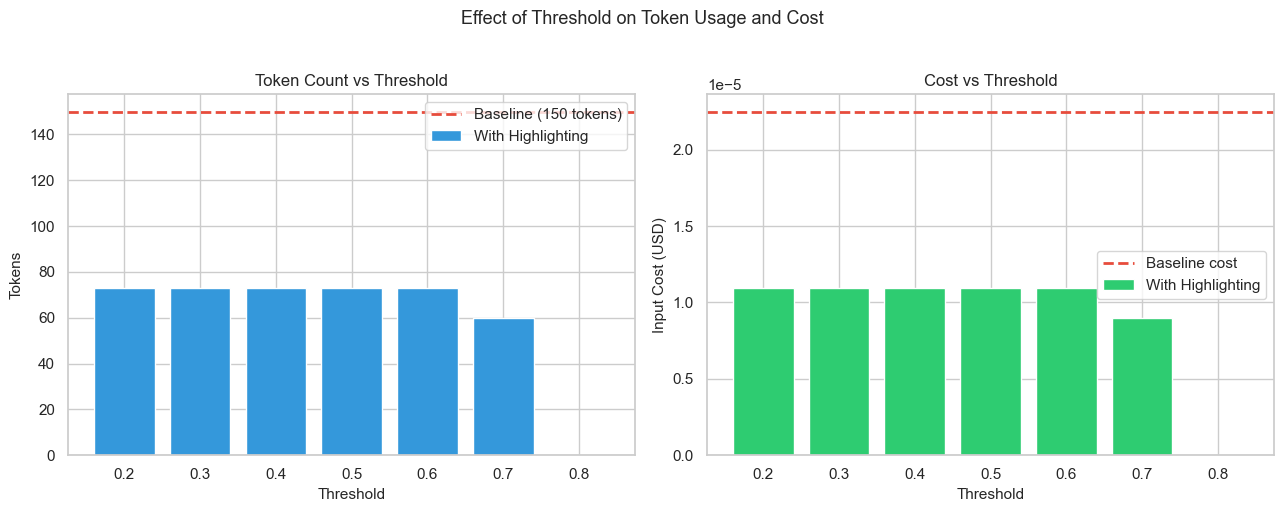

In [11]:
# ── Visualise cost vs threshold ───────────────────────────────────────────────
th_vals   = [d[0] for d in threshold_data]
tok_vals  = [d[2] for d in threshold_data]
cost_vals = [d[2] / 1_000_000 * 0.150 for d in threshold_data]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Tokens
ax1.bar([str(t) for t in th_vals], tok_vals, color="#3498db", label="With Highlighting")
ax1.axhline(original_tokens, color="#e74c3c", linestyle="--", linewidth=2,
            label=f"Baseline ({original_tokens} tokens)")
ax1.set_xlabel("Threshold", fontsize=11)
ax1.set_ylabel("Tokens", fontsize=11)
ax1.set_title("Token Count vs Threshold", fontsize=12)
ax1.legend()

# Cost
ax2.bar([str(t) for t in th_vals], cost_vals, color="#2ecc71", label="With Highlighting")
ax2.axhline(original_tokens / 1_000_000 * 0.150, color="#e74c3c", linestyle="--",
            linewidth=2, label="Baseline cost")
ax2.set_xlabel("Threshold", fontsize=11)
ax2.set_ylabel("Input Cost (USD)", fontsize=11)
ax2.set_title("Cost vs Threshold", fontsize=12)
ax2.legend()

fig.suptitle("Effect of Threshold on Token Usage and Cost", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## Section 4 — PART 2: Hallucination Detection with HHEM

### The Problem

Even after good retrieval, LLMs can **hallucinate** — generate confident answers with facts that are not in the context or are simply wrong.  
This is dangerous because the output *looks* correct.

Example:
> **Context says:** "Sea levels have risen by roughly 20 cm over the last century."  
> **LLM says:** "Sea levels have risen by 2 metres over the last 50 years." ← Hallucinated!

### The Solution: HHEM (Hughes Hallucination Evaluation Model)

The `vectara/hallucination_evaluation_model` model checks whether an answer is **supported by** the given context.  
It outputs a **faithfulness score** from 0 to 1:

| Score range | Interpretation |
|---|---|
| 0.0 – 0.4 | High likelihood of hallucination |
| 0.4 – 0.6 | Uncertain — manual review recommended |
| 0.6 – 1.0 | High confidence the answer is faithful |

Default threshold is **0.5**: if `score < 0.5`, the answer is flagged as hallucinated.

In [12]:
# ── Define our test context and two answers ───────────────────────────────────

CLIMATE_CONTEXT = """Global temperatures have risen by approximately 1.1°C since the pre-industrial era.
Carbon dioxide levels in the atmosphere reached 421 ppm in 2023.
Sea levels have risen by roughly 20 cm over the last century."""

# ✅ Faithful answer — every claim is directly from the context
FAITHFUL_ANSWER = (
    "Global temperatures have risen by about 1.1°C since pre-industrial times. "
    "CO2 levels reached 421 ppm in 2023, and sea levels have risen approximately "
    "20 cm over the past century."
)

# ❌ Hallucinated answer — invented numbers that are NOT in the context
HALLUCINATED_ANSWER = (
    "Global temperatures have risen by 3.5°C since 1800. "
    "CO2 levels are now at 600 ppm and sea levels have surged by "
    "1 metre in the last 50 years."
)

print("Context:")
print("-" * 60)
print(CLIMATE_CONTEXT)
print()
print("✅ Faithful answer:")
print(FAITHFUL_ANSWER)
print()
print("❌ Hallucinated answer:")
print(HALLUCINATED_ANSWER)

Context:
------------------------------------------------------------
Global temperatures have risen by approximately 1.1°C since the pre-industrial era.
Carbon dioxide levels in the atmosphere reached 421 ppm in 2023.
Sea levels have risen by roughly 20 cm over the last century.

✅ Faithful answer:
Global temperatures have risen by about 1.1°C since pre-industrial times. CO2 levels reached 421 ppm in 2023, and sea levels have risen approximately 20 cm over the past century.

❌ Hallucinated answer:
Global temperatures have risen by 3.5°C since 1800. CO2 levels are now at 600 ppm and sea levels have surged by 1 metre in the last 50 years.


In [13]:
# ── Run HHEM validation on both answers ───────────────────────────────────────
faithful_result     = validator.validate(context=CLIMATE_CONTEXT, answer=FAITHFUL_ANSWER)
hallucinated_result = validator.validate(context=CLIMATE_CONTEXT, answer=HALLUCINATED_ANSWER)

print("╔══════════════════════════════════════════════════════════╗")
print("║  HHEM Validation Results                                 ║")
print("╠══════════════════════════════════════════════════════════╣")
print(f"║  ✅ Faithful Answer                                      ║")
print(f"║     HHEM Score      : {faithful_result['score']:.3f}                            ║")
print(f"║     Flagged?        : {str(faithful_result['is_hallucinated']):<38}║")
print("╠══════════════════════════════════════════════════════════╣")
print(f"║  ❌ Hallucinated Answer                                  ║")
print(f"║     HHEM Score      : {hallucinated_result['score']:.3f}                            ║")
print(f"║     Flagged?        : {str(hallucinated_result['is_hallucinated']):<38}║")
print("╚══════════════════════════════════════════════════════════╝")

╔══════════════════════════════════════════════════════════╗
║  HHEM Validation Results                                 ║
╠══════════════════════════════════════════════════════════╣
║  ✅ Faithful Answer                                      ║
║     HHEM Score      : 0.898                            ║
║     Flagged?        : False                                 ║
╠══════════════════════════════════════════════════════════╣
║  ❌ Hallucinated Answer                                  ║
║     HHEM Score      : 0.063                            ║
║     Flagged?        : True                                  ║
╚══════════════════════════════════════════════════════════╝


### Visualisation 3 — HHEM Score Gauge

The needle points toward the faithfulness score.  
- Left (red zone) = hallucination risk  
- Right (green zone) = faithful answer

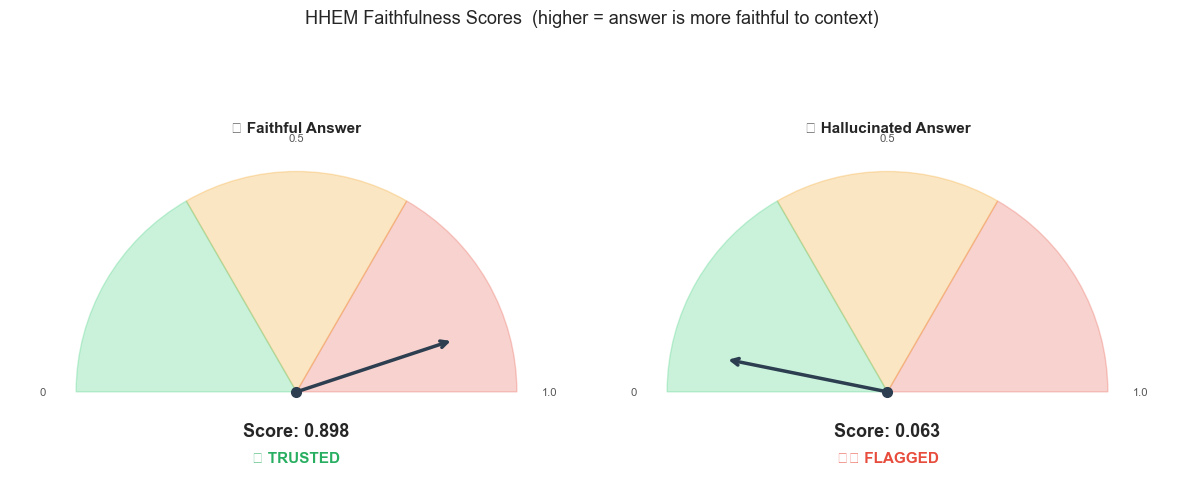

In [14]:
from matplotlib.patches import Wedge

def draw_gauge(ax, score, title, flagged):
    """Draw a semicircular gauge for an HHEM score."""
    ax.set_xlim(-1.3, 1.3)
    ax.set_ylim(-0.35, 1.3)
    ax.set_aspect("equal")
    ax.axis("off")

    # Background arc segments
    ax.add_patch(Wedge((0, 0), 1, 0,   60,  color="#e74c3c", alpha=0.25))   # 0–0.33
    ax.add_patch(Wedge((0, 0), 1, 60,  120, color="#f39c12", alpha=0.25))   # 0.33–0.67
    ax.add_patch(Wedge((0, 0), 1, 120, 180, color="#2ecc71", alpha=0.25))   # 0.67–1.0

    # Needle
    rad = np.radians(180 - score * 180)
    ax.annotate(
        "", xy=(0.75 * np.cos(rad), 0.75 * np.sin(rad)), xytext=(0, 0),
        arrowprops=dict(arrowstyle="->", lw=2.5, color="#2c3e50")
    )
    ax.plot(0, 0, "o", color="#2c3e50", markersize=7, zorder=5)

    # Labels
    ax.text(0, -0.2, f"Score: {score:.3f}", ha="center", fontsize=13, fontweight="bold")
    status = "⚠️ FLAGGED" if flagged else "✅ TRUSTED"
    colour = "#e74c3c" if flagged else "#27ae60"
    ax.text(0, -0.32, status, ha="center", fontsize=11, color=colour, fontweight="bold")
    ax.text(0, 1.18, title, ha="center", fontsize=11, fontweight="bold")

    # Scale ticks
    for val, lbl in [(0, "0"), (0.5, "0.5"), (1, "1.0")]:
        r = np.radians(180 - val * 180)
        ax.text(1.15 * np.cos(r), 1.15 * np.sin(r), lbl,
                ha="center", va="center", fontsize=8, color="#555")


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
draw_gauge(ax1, faithful_result["score"],     "✅ Faithful Answer",     faithful_result["is_hallucinated"])
draw_gauge(ax2, hallucinated_result["score"], "❌ Hallucinated Answer", hallucinated_result["is_hallucinated"])

fig.suptitle("HHEM Faithfulness Scores  (higher = answer is more faithful to context)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Visualisation 4 — Threshold Sensitivity

The threshold determines **how strict** the hallucination check is.  
Below we show what each threshold would decide for our two answers.

In [15]:
thresholds_hhem = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

faithful_score     = faithful_result["score"]
hallucinated_score = hallucinated_result["score"]

print(f"Faithful answer HHEM score     : {faithful_score:.3f}")
print(f"Hallucinated answer HHEM score : {hallucinated_score:.3f}")
print()
print(f"{'Threshold':<12} {'Faithful flagged?':<22} {'Hallucinated flagged?':<22} {'Both correct?'}")
print("-" * 75)

for t in thresholds_hhem:
    f_flagged = faithful_score < t
    h_flagged = hallucinated_score < t
    both_ok   = (not f_flagged) and h_flagged
    print(f"{t:<12} {str(f_flagged):<22} {str(h_flagged):<22} {'✅' if both_ok else '❌'}")

Faithful answer HHEM score     : 0.898
Hallucinated answer HHEM score : 0.063

Threshold    Faithful flagged?      Hallucinated flagged?  Both correct?
---------------------------------------------------------------------------
0.2          False                  True                   ✅
0.3          False                  True                   ✅
0.4          False                  True                   ✅
0.5          False                  True                   ✅
0.6          False                  True                   ✅
0.7          False                  True                   ✅
0.8          False                  True                   ✅


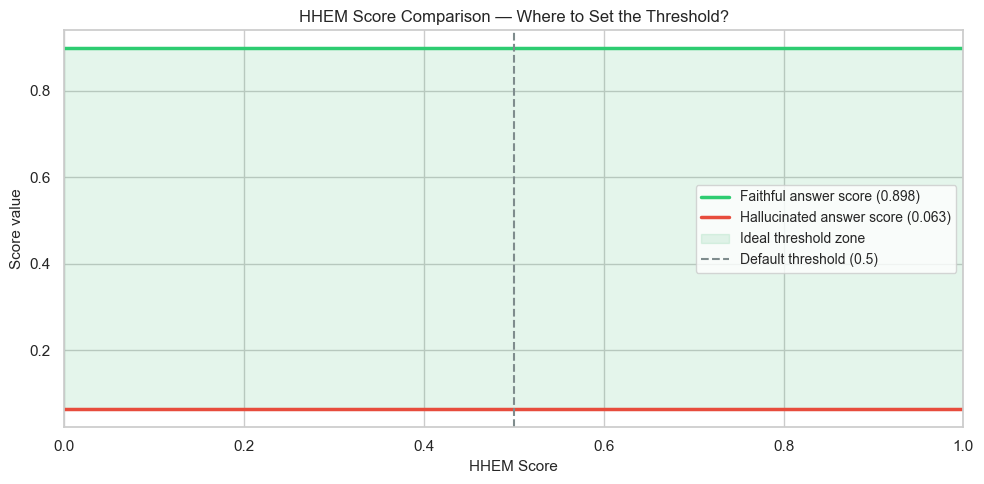


The green band shows the range of thresholds that correctly separate
the faithful answer from the hallucinated one.


In [16]:
# ── Visualise both scores against moving threshold line ───────────────────────
t_range = np.linspace(0, 1, 200)

fig, ax = plt.subplots(figsize=(10, 5))

ax.axhline(faithful_score,     color="#2ecc71", linewidth=2.5,
           label=f"Faithful answer score ({faithful_score:.3f})")
ax.axhline(hallucinated_score, color="#e74c3c", linewidth=2.5,
           label=f"Hallucinated answer score ({hallucinated_score:.3f})")

# Shade the region where ONLY the hallucinated answer is flagged (ideal zone)
ideal_lo = hallucinated_score
ideal_hi = faithful_score
if ideal_lo < ideal_hi:
    ax.axhspan(ideal_lo, ideal_hi, alpha=0.12, color="#27ae60",
               label="Ideal threshold zone")

ax.set_xlabel("HHEM Score", fontsize=11)
ax.set_ylabel("Score value", fontsize=11)
ax.set_title("HHEM Score Comparison — Where to Set the Threshold?", fontsize=12)
ax.axvline(0.5, color="#7f8c8d", linestyle="--", linewidth=1.5,
           label="Default threshold (0.5)")
ax.set_xlim(0, 1)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()
print()
print("The green band shows the range of thresholds that correctly separate")
print("the faithful answer from the hallucinated one.")

---
## Section 5 — Combined Summary: Three RAG Modes Side-by-Side

Now let's compare all three pipeline modes using numbers from what we've computed:

Prepare contexts: 100%|██████████| 1/1 [00:00<00:00, 2178.86it/s]

[OpenProvenceModel] Model inference time: 0.03s (1 blocks)


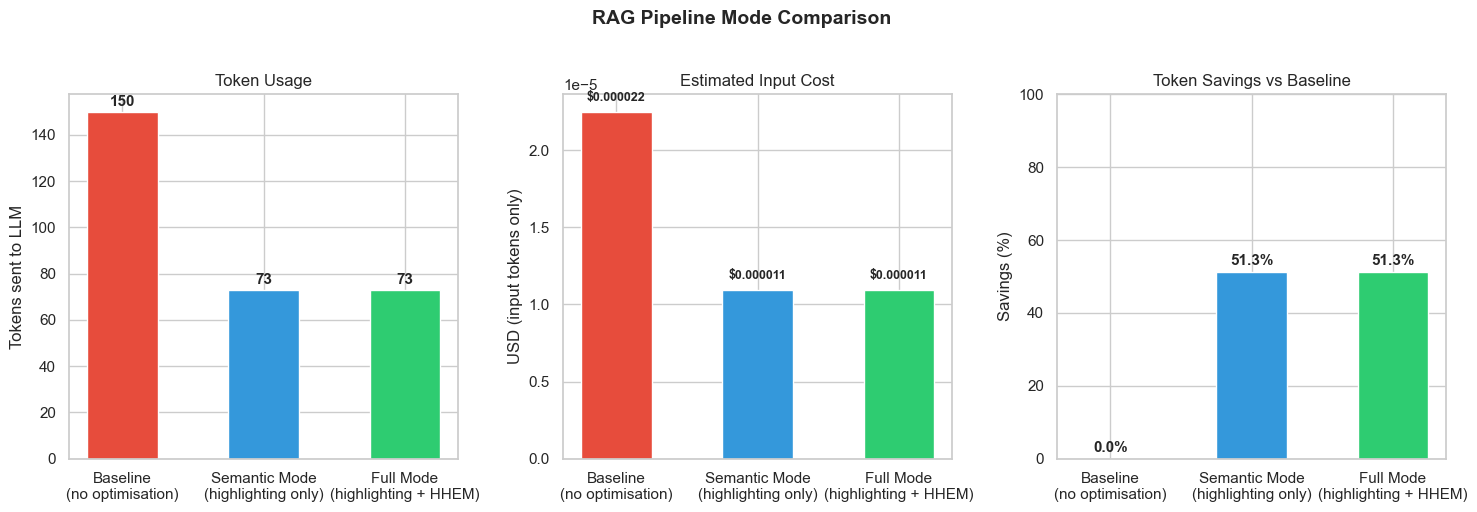


KEY INSIGHT:
  Semantic + Full modes send 73 tokens vs 150 for Baseline.
  That is a 51.3% reduction — for every 1,000 queries, this saves
  ~$0.0115 in input costs.


In [17]:
# Use the numbers we already computed above
result_default = highlighter.highlight(QUERY, TOPIC_CONTEXT, threshold=0.5)
pruned_text    = "\n".join(result_default["highlighted_sentences"])
pruned_tok     = len(enc.encode(pruned_text))

modes         = ["Baseline\n(no optimisation)",
                 "Semantic Mode\n(highlighting only)",
                 "Full Mode\n(highlighting + HHEM)"]
token_counts  = [original_tokens, pruned_tok, pruned_tok]
input_costs   = [t / 1_000_000 * 0.150 for t in token_counts]
savings_pcts  = [0, (original_tokens - pruned_tok) / original_tokens * 100,
                 (original_tokens - pruned_tok) / original_tokens * 100]
bar_colours   = ["#e74c3c", "#3498db", "#2ecc71"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Tokens
axes[0].bar(modes, token_counts, color=bar_colours, edgecolor="white", width=0.5)
axes[0].set_title("Token Usage", fontsize=12)
axes[0].set_ylabel("Tokens sent to LLM")
for i, v in enumerate(token_counts):
    axes[0].text(i, v + 1, str(v), ha="center", va="bottom", fontsize=11, fontweight="bold")

# Cost
axes[1].bar(modes, input_costs, color=bar_colours, edgecolor="white", width=0.5)
axes[1].set_title("Estimated Input Cost", fontsize=12)
axes[1].set_ylabel("USD (input tokens only)")
for i, v in enumerate(input_costs):
    axes[1].text(i, v + 0.0000005, f"${v:.6f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

# Savings %
axes[2].bar(modes, savings_pcts, color=bar_colours, edgecolor="white", width=0.5)
axes[2].set_title("Token Savings vs Baseline", fontsize=12)
axes[2].set_ylabel("Savings (%)")
axes[2].set_ylim(0, 100)
for i, v in enumerate(savings_pcts):
    axes[2].text(i, v + 1, f"{v:.1f}%", ha="center", va="bottom", fontsize=11, fontweight="bold")

fig.suptitle("RAG Pipeline Mode Comparison", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print()
print("KEY INSIGHT:")
print(f"  Semantic + Full modes send {pruned_tok} tokens vs {original_tokens} for Baseline.")
print(f"  That is a {savings_pcts[1]:.1f}% reduction — for every 1,000 queries, this saves")
print(f"  ~${savings_pcts[1]/100 * original_tokens * 1000 / 1_000_000 * 0.150:.4f} in input costs.")

---
## Section 6 — End-to-End Pipeline (Optional)

> **Requirements:** Qdrant running on `localhost:6333` **and** `OPENAI_API_KEY` set in `.env`.  
> If you don't have these, skip this section — everything above works without them.

This section shows the complete pipeline using `RAGEngine` directly, exactly as the FastAPI app does.

In [18]:
# ── Optional: End-to-end using RAGEngine ─────────────────────────────────────

from app.services.rag_engine import RAGEngine
from app.services.vector_store import VectorStore
from app.services.document_processor import DocumentProcessor
from app.models import QueryMode
from langchain_core.documents import Document
vector_store = VectorStore()
engine = RAGEngine(
    vector_store=vector_store,
    semantic_highlighter=highlighter,
    hhem_validator=validator,
)
# First, ingest the climate context as a document
processor = DocumentProcessor()
# Convert context to a LangChain Document and specify the filename argument
raw_docs = [Document(page_content=TOPIC_CONTEXT, metadata={"source": "notebook"})]
chunks = processor.chunk_documents(raw_docs, filename="notebook")
vector_store.add_documents(chunks)
# Run all three modes
for mode in [QueryMode.BASELINE, QueryMode.SEMANTIC, QueryMode.FULL]:
    resp = engine.query(QUERY, mode=mode, top_k=3)
    print(f"=== {mode.value.upper()} ===")
    print(f"Answer         : {resp.answer}")
    print(f"Tokens (input) : {resp.metrics.original_tokens} → {resp.metrics.pruned_tokens or resp.metrics.original_tokens}")
    print(f"Token savings  : {resp.metrics.token_savings_pct or 0:.1f}%")
    print(f"HHEM score     : {resp.metrics.hhem_score}")
    print(f"Hallucinated?  : {resp.metrics.is_hallucinated}")
    if resp.warning:
        print(f"Warning        : {resp.warning}")
    print()


2026-05-21 16:14:40.190 | WARNING  | app.services.rag_engine:__init__:39 - Could not automatically map model 'openai/gpt-5.4' to a tokenizer. Defaulting to 'cl100k_base'.
2026-05-21 16:14:40.237 | INFO     | app.services.document_processor:chunk_documents:82 - Chunking 1 documents
2026-05-21 16:14:40.238 | INFO     | app.services.document_processor:chunk_documents:87 - Created 2 chunks
2026-05-21 16:14:40.238 | INFO     | app.services.vector_store:add_documents:69 - Adding 2 chunks to vector store
2026-05-21 16:14:51.937 | INFO     | app.services.vector_store:add_documents:90 - Successfully added 2 points
2026-05-21 16:14:51.938 | INFO     | app.services.rag_engine:query_baseline:97 - [BASELINE] Processing: What are the main effects of climate change on the environment?
2026-05-21 16:14:51.939 | INFO     | app.services.vector_store:search:98 - Searching for: 'What are the main effects of climate change on the environment?' (top_k=3)
2026-05-21 16:14:53.244 | INFO     | app.services.vec

=== BASELINE ===
Answer         : The main environmental effects mentioned are:

- Rising global temperatures, about 1.1°C since the pre-industrial era
- Accelerating melting of the Greenland and Antarctic ice sheets
- Sea level rise, roughly 20 cm over the last century
Tokens (input) : 320 → 320
Token savings  : 0.0%
HHEM score     : None
Hallucinated?  : None



2026-05-21 16:15:11.206 | INFO     | app.services.vector_store:search:132 - Found 3 results
Prepare contexts: 100%|██████████| 1/1 [00:00<00:00, 705.76it/s]


[OpenProvenceModel] Model inference time: 0.37s (1 blocks)


Prepare contexts: 100%|██████████| 1/1 [00:00<00:00, 2023.30it/s]

...


Prepare contexts: 100%|██████████| 1/1 [00:00<00:00, 2252.58it/s]

[OpenProvenceModel] Model inference time: 0.01s (1 blocks)



Prepare contexts: 100%|██████████| 1/1 [00:00<00:00, 2605.16it/s]

[OpenProvenceModel] Model inference time: 0.01s (1 blocks)


=== FULL ===
Answer         : The main environmental effects mentioned are:

- Rising global temperatures, about 1.1°C since the pre-industrial era  
- Accelerating melting of the Greenland and Antarctic ice sheets  
- Higher atmospheric carbon dioxide levels, reaching 421 ppm in 2023  
- Rising sea levels, about 20 cm over the last century
Tokens (input) : 320 → 182
Token savings  : 43.1%
HHEM score     : 0.9646594524383545
Hallucinated?  : False



---
## Section 7 — Student Exercises

Work through these exercises to deepen your understanding. Each builds on the code above.

### Exercise 1 — Change the Query (Easy)

Change `QUERY` to something unrelated to climate change, such as:
> `"Who painted the Mona Lisa?"`

Re-run **Section 3, Cells 1–3**.  
- Which sentences now score high?  
- What happened to the climate sentences?  
- What does this tell you about how semantic highlighting works?

In [24]:
# ── Exercise 1 workspace ─────────────────────────────────────────────────────
EX1_QUERY = "Who painted the Mona Lisa?"   # <-- change this

ex1_result = highlighter.highlight(query=EX1_QUERY, context=TOPIC_CONTEXT, threshold=0.5)

print(f"Query: {EX1_QUERY}")
print(f"Sentences kept: {len(ex1_result['highlighted_sentences'])}")
print()
print("Kept sentences:")
for s in ex1_result["highlighted_sentences"]:
    print(f"  • {s}")
print()
print("Per-sentence scores:")
for sent, score in zip(
    TOPIC_CONTEXT.strip().splitlines(), ex1_result["sentence_probabilities"]
):
    bar = "█" * int(score * 20)
    print(f"  {score:.2f} {bar:<20}  {sent.strip()[:60]}")

Prepare contexts: 100%|██████████| 1/1 [00:00<00:00, 1183.83it/s]


[OpenProvenceModel] Model inference time: 0.13s (1 blocks)
Query: Who painted the Mona Lisa?
Sentences kept: 1

Kept sentences:
  • Leonardo da Vinci painted the Mona Lisa around 1503.


Per-sentence scores:
  0.00                       Global temperatures have risen by approximately 1.1°C since 
  0.00                       The Amazon rainforest covers about 5.5 million square kilome
  0.00                       Ice sheets in Greenland and Antarctica are melting at an acc
  0.00                       The capital of France is Paris, which has a population of ab
  0.00                       Carbon dioxide levels in the atmosphere reached 421 ppm in 2
  0.00                       Sea levels have risen by roughly 20 cm over the last century
  0.98 ███████████████████   Leonardo da Vinci painted the Mona Lisa around 1503.
  0.00                       Extreme weather events including hurricanes and droughts are
  0.00                       The Eiffel Tower was completed in 1889 and stands 3

### Exercise 2 — Strict Threshold (Medium)

Set `threshold=0.9` in the cell below and run it.  
- How many sentences are kept?  
- Is the remaining context still enough to answer the question?  
- What is the risk of setting the threshold too high in production?

In [25]:
# ── Exercise 2 workspace ─────────────────────────────────────────────────────
EX2_THRESHOLD = 0.9   # <-- change this and re-run

ex2_result = highlighter.highlight(query=QUERY, context=TOPIC_CONTEXT, threshold=EX2_THRESHOLD)
ex2_text   = "\n".join(ex2_result["highlighted_sentences"])
ex2_tokens = len(enc.encode(ex2_text))

print(f"Threshold       : {EX2_THRESHOLD}")
print(f"Sentences kept  : {len(ex2_result['highlighted_sentences'])} / {len(TOPIC_CONTEXT.strip().splitlines())}")
print(f"Tokens          : {ex2_tokens} (vs {original_tokens} baseline)")
print(f"Token savings   : {(original_tokens - ex2_tokens)/original_tokens*100:.1f}%")
print()
print("Context that would be sent to LLM:")
print(ex2_text if ex2_text else "(nothing kept — threshold too strict!)")

Prepare contexts: 100%|██████████| 1/1 [00:00<00:00, 410.12it/s]


[OpenProvenceModel] Model inference time: 0.14s (1 blocks)
Threshold       : 0.9
Sentences kept  : 0 / 10
Tokens          : 0 (vs 150 baseline)
Token savings   : 100.0%

Context that would be sent to LLM:
(nothing kept — threshold too strict!)


### Exercise 3 — Write Your Own Hallucinated Answer (Medium)

Using `CLIMATE_CONTEXT` from Section 4, write an answer that:
- Sounds plausible
- Contains at least one number that is NOT in the context

Run it through HHEM. Does it get flagged? What score does it receive?

In [26]:
# ── Exercise 3 workspace ─────────────────────────────────────────────────────
MY_ANSWER = (
    "Temperatures have risen by 2°C and CO2 is now at 500 ppm."
    # <-- replace this with your own answer
)

my_result = validator.validate(context=CLIMATE_CONTEXT, answer=MY_ANSWER)
print(f"Your answer  : {MY_ANSWER}")
print(f"HHEM score   : {my_result['score']:.3f}")
print(f"Flagged?     : {my_result['is_hallucinated']}")

verdict = "⚠️  HHEM caught the hallucination!" if my_result["is_hallucinated"] else "✅  HHEM considers this faithful."
print(f"Verdict      : {verdict}")

Your answer  : Temperatures have risen by 2°C and CO2 is now at 500 ppm.
HHEM score   : 0.071
Flagged?     : True
Verdict      : ⚠️  HHEM caught the hallucination!


### Exercise 4 — Subtle Hallucination (Hard)

Write an answer that is **mostly faithful** but changes **one small detail** (e.g. "20 cm" → "25 cm").  
What score does HHEM give? Does it flag it?  
What does this tell you about the limits of automated hallucination detection?

In [27]:
# ── Exercise 4 workspace ─────────────────────────────────────────────────────
SUBTLE_ANSWER = (
    "Global temperatures have risen by about 1.1°C since pre-industrial times. "
    "CO2 levels reached 421 ppm in 2023, and sea levels have risen approximately "
    "25 cm over the past century."   # 25 cm — context says 20 cm
)

subtle_result = validator.validate(context=CLIMATE_CONTEXT, answer=SUBTLE_ANSWER)
print(f"Answer       : {SUBTLE_ANSWER}")
print(f"HHEM score   : {subtle_result['score']:.3f}")
print(f"Flagged?     : {subtle_result['is_hallucinated']}")
print()
print("Compare:")
print(f"  Fully faithful    : {faithful_result['score']:.3f}")
print(f"  Subtly wrong      : {subtle_result['score']:.3f}")
print(f"  Fully hallucinated: {hallucinated_result['score']:.3f}")

Answer       : Global temperatures have risen by about 1.1°C since pre-industrial times. CO2 levels reached 421 ppm in 2023, and sea levels have risen approximately 25 cm over the past century.
HHEM score   : 0.378
Flagged?     : True

Compare:
  Fully faithful    : 0.898
  Subtly wrong      : 0.378
  Fully hallucinated: 0.063


### Bonus Exercise — Combined Thresholds

Try `semantic_threshold=0.2` (very lenient) and `hhem_threshold=0.8` (very strict).  
Run both the highlighting and validation steps.

- When would you choose a **lenient** highlighting threshold in production?
- When would you choose a **strict** HHEM threshold?
- What is the cost of each mistake (false positive vs false negative)?

Think about use cases like: medical advice, customer service, legal documents, casual Q&A.

In [28]:
# ── Bonus workspace ──────────────────────────────────────────────────────────
BONUS_SEM_THRESHOLD  = 0.2   # <-- change me
BONUS_HHEM_THRESHOLD = 0.8   # <-- change me

bonus_high = highlighter.highlight(QUERY, TOPIC_CONTEXT, threshold=BONUS_SEM_THRESHOLD)
bonus_tok  = len(enc.encode("\n".join(bonus_high["highlighted_sentences"])))

bonus_val_faithful     = validator.validate(CLIMATE_CONTEXT, FAITHFUL_ANSWER,     threshold=BONUS_HHEM_THRESHOLD)
bonus_val_hallucinated = validator.validate(CLIMATE_CONTEXT, HALLUCINATED_ANSWER, threshold=BONUS_HHEM_THRESHOLD)

print(f"Semantic threshold={BONUS_SEM_THRESHOLD}:")
print(f"  Sentences kept : {len(bonus_high['highlighted_sentences'])}, tokens: {bonus_tok}")
print()
print(f"HHEM threshold={BONUS_HHEM_THRESHOLD}:")
print(f"  Faithful answer    flagged? {bonus_val_faithful['is_hallucinated']}  (score: {bonus_val_faithful['score']:.3f})")
print(f"  Hallucinated answer flagged? {bonus_val_hallucinated['is_hallucinated']}  (score: {bonus_val_hallucinated['score']:.3f})")

Prepare contexts: 100%|██████████| 1/1 [00:00<00:00, 745.52it/s]


[OpenProvenceModel] Model inference time: 0.15s (1 blocks)
Semantic threshold=0.2:
  Sentences kept : 5, tokens: 73

HHEM threshold=0.8:
  Faithful answer    flagged? False  (score: 0.898)
  Hallucinated answer flagged? True  (score: 0.063)


---
## Summary

| | What it does | When to use |
|---|---|---|
| **Baseline RAG** | Retrieve → LLM → Answer | Simple prototypes, when cost is not a concern |
| **Semantic Highlighting** | Prune irrelevant sentences before LLM | Production RAG with cost optimisation goals |
| **HHEM Validation** | Score answer faithfulness after generation | High-stakes use cases (medical, legal, finance) |
| **Full Mode** | Highlighting + HHEM together | Best quality + safety combination |

**Key numbers to remember:**
- Semantic highlighting can save **30–70% of input tokens**
- GPT-4o-mini costs **$0.15 / 1M input tokens** — at scale, highlighting pays for itself quickly
- HHEM score **≥ 0.5** = trusted answer, **< 0.5** = review required (default threshold)

---
*Notebook built for the `HighHEM` project.*